# A/B Test Analysis

## Objective

Evaluate whether Variant B improves paid subscription conversion compared with Variant A.

### Primary Metric

- Paid Conversion Rate

### Secondary Metrics

- Average Revenue per Paying User (ARPU)
- Total Revenue

---

## Hypotheses

### Null Hypothesis (H₀)

There is no difference in paid conversion rate between Variant A and Variant B.

### Alternative Hypothesis (H₁)

Variant B has a different paid conversion rate than Variant A.

---

## Experiment Summary

Users were randomly assigned to one of two variants:

- Variant A (Control)
- Variant B (Treatment)

The objective is to determine whether the treatment produced a statistically significant improvement in paid conversion.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chisquare

from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep
)

plt.style.use("ggplot")

# Load experiment dataset

In [4]:
df = pd.read_csv("../data/experiment_dataset.csv")

df.head()

,user_id,variant,signup_date,device,country,acquisition_channel,pre_engagement_7d,converted,retained,revenue
0,1,A,2024-10-19,mobile,UK,Organic,11,0,0,0.0
1,2,A,2024-06-24,desktop,US,Paid Search,14,0,0,0.0
2,3,B,2024-11-15,desktop,UK,Paid Search,7,0,0,0.0
3,4,B,2024-09-23,mobile,UK,Paid Search,14,0,0,0.0
4,5,B,2024-02-10,mobile,IN,Email,9,0,0,0.0


In [5]:
print(df.shape)

(40000, 10)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              40000 non-null  int64  
 1   variant              40000 non-null  object 
 2   signup_date          40000 non-null  object 
 3   device               40000 non-null  object 
 4   country              38866 non-null  object 
 5   acquisition_channel  40000 non-null  object 
 6   pre_engagement_7d    40000 non-null  int64  
 7   converted            40000 non-null  int64  
 8   retained             40000 non-null  int64  
 9   revenue              40000 non-null  float64
dtypes: float64(1), int64(4), object(5)
memory usage: 3.1+ MB


In [7]:
summary = (
    df.groupby("variant")
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum"),
          retained=("retained", "sum"),
          total_revenue=("revenue", "sum"),
          average_revenue_per_user=("revenue", "mean")
      )
)

summary["conversion_rate"] = (
    summary["conversions"]
    / summary["users"]
)

summary

,users,conversions,retained,total_revenue,average_revenue_per_user,conversion_rate
variant,,,,,,
A,19818,3440,2120,212616.0,10.728429,0.173580
B,20182,4083,2622,263820.0,13.072044,0.202309


## Initial Summary

The experiment contains approximately 20,000 users in each variant.

Variant B shows a higher observed paid conversion rate than Variant A prior to formal statistical testing.

In [16]:
variants = summary.index.to_list()

users = summary["users"].to_numpy()

conversions = summary["conversions"].to_numpy()

conversion_rates = summary["conversion_rate"].to_numpy()

total_revenue = summary["total_revenue"].to_numpy()

average_revenue_per_user = (
    summary["average_revenue_per_user"].to_numpy()
)

## Initial Observations

Before performing hypothesis testing, inspect the basic experiment metrics.

Questions:

- Was the experiment evenly split?
- Which variant converted better?
- Is there an obvious revenue difference?

In [4]:
absolute_uplift = conversion_rates[1] - conversion_rates[0]

relative_uplift = (
    absolute_uplift
    / conversion_rates[0]
) * 100

print(f"Variant A Conversion Rate : {conversion_rates[0]:.2%}")
print(f"Variant B Conversion Rate : {conversion_rates[1]:.2%}")

print()

print(f"Absolute Uplift : {absolute_uplift:.2%}")
print(f"Relative Uplift : {relative_uplift:.2f}%")

Variant A Conversion Rate : 17.36%
Variant B Conversion Rate : 20.23%

Absolute Uplift : 2.87%
Relative Uplift : 16.55%


## Visualization

Visualize the conversion rate for each experiment variant.

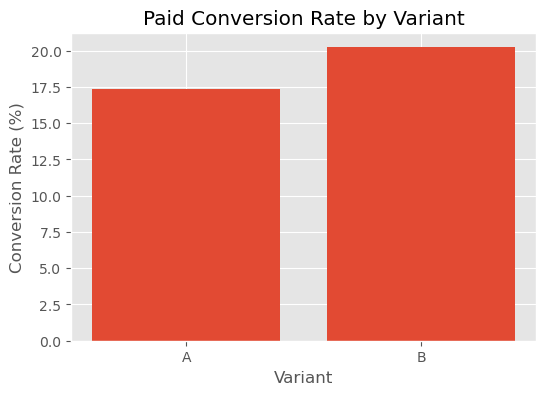

In [5]:
plt.figure(figsize=(6,4))

plt.bar(
    variants,
    conversion_rates * 100
)

plt.title("Paid Conversion Rate by Variant")

plt.ylabel("Conversion Rate (%)")

plt.xlabel("Variant")

plt.show()

## Sample Ratio Mismatch (SRM)

Before evaluating the experiment outcome, verify that users were assigned evenly between the two variants.

A significant imbalance may indicate an experiment implementation problem.

In [6]:
expected = [
    users.sum() / 2,
    users.sum() / 2
]

chi2, p = chisquare(
    f_obs=users,
    f_exp=expected
)

print("Chi-square statistic:", round(chi2, 4))

print("P-value:", round(p, 4))

Chi-square statistic: 3.3124
P-value: 0.0688


In [7]:
if p < 0.001:
    print("⚠️ Sample Ratio Mismatch detected.")
else:
    print("✅ Experiment allocation appears balanced.")

✅ Experiment allocation appears balanced.


## Two-Proportion Z-Test

The experiment assignment was balanced, so we can now evaluate whether the observed difference in paid conversion rates between Variant A and Variant B is statistically significant.

This test compares the conversion rates of the two variants under the following hypotheses:

**Null Hypothesis (H₀):**

There is no difference in paid conversion rate between Variant A and Variant B.

**Alternative Hypothesis (H₁):**

There is a difference in paid conversion rate between Variant A and Variant B.

In [8]:
z_stat, p_value = proportions_ztest(

    count=conversions,

    nobs=users

)

print(f"Z-statistic: {z_stat:.4f}")

print(f"P-value: {p_value:.6f}")

Z-statistic: -7.3517
P-value: 0.000000


In [9]:
alpha = 0.05

if p_value < alpha:
    print("✅ Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("❌ Fail to reject the null hypothesis.")
    print("The observed difference could be due to random chance.")

✅ Reject the null hypothesis.
The difference in conversion rates is statistically significant.


## 95% Confidence Interval

While the hypothesis test tells us whether a statistically significant difference exists, a confidence interval estimates the range of plausible values for the true difference in conversion rates.

This helps quantify the magnitude and uncertainty of the observed uplift.

In [11]:
ci_low, ci_high = confint_proportions_2indep(
    count1=conversions[0],
    nobs1=users[0],
    count2=conversions[1],
    nobs2=users[1],
    method="wald"
)

print(f"95% Confidence Interval: ({ci_low:.4%}, {ci_high:.4%})")

95% Confidence Interval: (-3.6379%, -2.1079%)


## Confidence Interval Interpretation

The 95% confidence interval for the difference in conversion rates is:

**(-3.64%, -2.11%)**

The interval is entirely below zero because the calculation measures **Variant A − Variant B**.

Equivalently, Variant B improves paid conversion by approximately **2.11 to 3.64 percentage points** compared with Variant A.

Since the interval does not include zero, the observed improvement is statistically significant at the 95% confidence level.

## Segment Analysis

Overall conversion improved with Variant B, but treatment effects can differ across user segments.

Understanding segment-level performance helps determine whether the experiment should be rolled out to all users or only specific user groups.

The following analyses evaluate conversion performance across:

- Device
- Acquisition Channel
- Country

### Conversion Rate by Device

Compare conversion performance between Variant A and Variant B across desktop and mobile users.

This helps determine whether the treatment performs consistently regardless of device type.

In [8]:
device_summary = (
    df.groupby(["device", "variant"])
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
      .reset_index()
)

device_summary["conversion_rate"] = (
    device_summary["conversions"]
    / device_summary["users"]
)

device_summary

,device,variant,users,conversions,conversion_rate
0,desktop,A,7595,1323,0.174194
1,desktop,B,7644,1460,0.190999
2,mobile,A,12223,2117,0.173198
3,mobile,B,12538,2623,0.209204


In [9]:
device_pivot = (
    device_summary.pivot(
        index="device",
        columns="variant",
        values="conversion_rate"
    )
)

(device_pivot * 100).round(2)

variant,A,B
device,,
desktop,17.42,19.10
mobile,17.32,20.92


<Figure size 700x400 with 0 Axes>

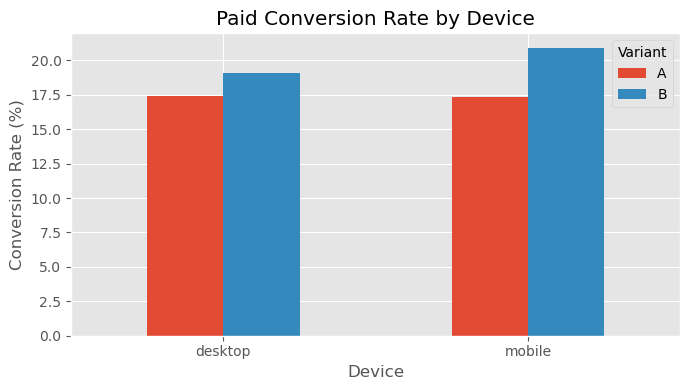

In [10]:
plt.figure(figsize=(7,4))

device_pivot.mul(100).plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Paid Conversion Rate by Device")

plt.xlabel("Device")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Variant")

plt.tight_layout()

plt.show()

### Interpretation

Variant B outperformed Variant A on both desktop and mobile devices.

- **Desktop:** Conversion increased from **17.42%** to **19.10%** (+1.68 percentage points).
- **Mobile:** Conversion increased from **17.32%** to **20.92%** (+3.60 percentage points).

The treatment produced a larger improvement for mobile users, suggesting that the new experience was particularly effective on mobile devices.

Since Variant B improved conversion across both device types, there is no evidence that the treatment negatively impacted a specific device segment.

## Acquisition Channel Analysis

Different acquisition channels attract users with different intent and behavior.

This analysis evaluates whether the treatment performs consistently across marketing channels.

In [11]:
channel_summary = (
    df.groupby(["acquisition_channel", "variant"])
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
      .reset_index()
)

channel_summary["conversion_rate"] = (
    channel_summary["conversions"]
    / channel_summary["users"]
)

channel_summary

,acquisition_channel,variant,users,conversions,conversion_rate
0,Email,A,1969,358,0.181818
1,Email,B,2063,431,0.208919
2,Organic,A,5983,1221,0.204078
3,Organic,B,6044,1444,0.238915
4,Paid Search,A,5420,756,0.139483
5,Paid Search,B,5669,908,0.160169
6,Referral,A,2483,534,0.215062
7,Referral,B,2398,580,0.241868
8,Social,A,3963,571,0.144083
9,Social,B,4008,720,0.179641


In [12]:
channel_pivot = (
    channel_summary.pivot(
        index="acquisition_channel",
        columns="variant",
        values="conversion_rate"
    )
)

(channel_pivot * 100).round(2)

variant,A,B
acquisition_channel,,
Email,18.18,20.89
Organic,20.41,23.89
Paid Search,13.95,16.02
Referral,21.51,24.19
Social,14.41,17.96


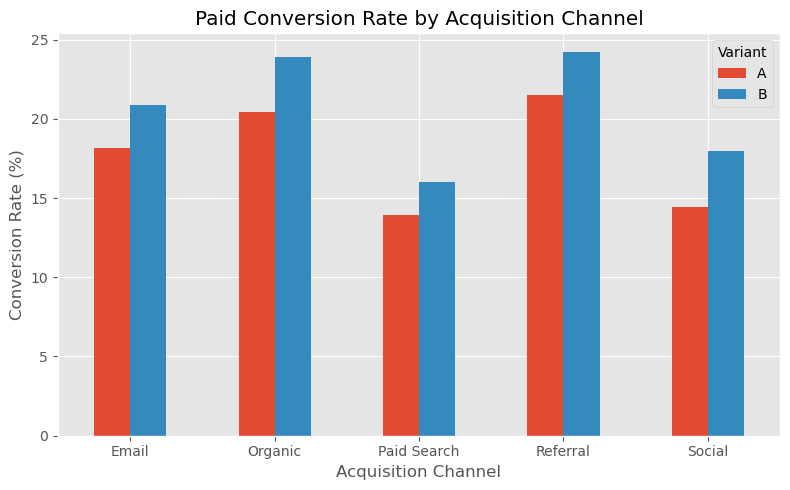

In [13]:
channel_pivot.mul(100).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Paid Conversion Rate by Acquisition Channel")

plt.xlabel("Acquisition Channel")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Variant")

plt.tight_layout()

plt.show()

### Interpretation

Variant B improved paid conversion across every acquisition channel.

- **Email:** Increased from **18.18%** to **20.89%** (+2.71 percentage points)
- **Organic:** Increased from **20.41%** to **23.89%** (+3.48 percentage points)
- **Paid Search:** Increased from **13.95%** to **16.02%** (+2.07 percentage points)
- **Referral:** Increased from **21.51%** to **24.19%** (+2.68 percentage points)
- **Social:** Increased from **14.41%** to **17.96%** (+3.55 percentage points)

The treatment consistently outperformed the control across all acquisition channels. The largest improvements were observed for **Social** and **Organic** users, while **Paid Search** showed the smallest uplift.

Since every acquisition channel experienced higher conversion under Variant B, the results suggest that the treatment is broadly effective rather than benefiting only a specific source of traffic.

## Country Analysis

User behavior can vary across geographic markets due to differences in customer preferences and purchasing behavior.

This analysis evaluates whether the treatment performs consistently across countries.

In [15]:
country_summary = (
    df.groupby(["country", "variant"])
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum")
      )
      .reset_index()
)

country_summary["conversion_rate"] = (
    country_summary["conversions"]
    / country_summary["users"]
)

country_summary

,country,variant,users,conversions,conversion_rate
0,BR,A,1582,245,0.154867
1,BR,B,1569,320,0.203952
2,CA,A,1930,306,0.158549
3,CA,B,1931,385,0.199379
4,DE,A,1879,346,0.184141
5,DE,B,1953,391,0.200205
6,IN,A,3892,690,0.177287
7,IN,B,3923,771,0.196533
8,UK,A,2247,376,0.167334
9,UK,B,2341,462,0.197352


In [16]:
country_pivot = (
    country_summary.pivot(
        index="country",
        columns="variant",
        values="conversion_rate"
    )
)

(country_pivot * 100).round(2)

variant,A,B
country,,
BR,15.49,20.40
CA,15.85,19.94
DE,18.41,20.02
IN,17.73,19.65
UK,16.73,19.74
US,17.97,20.85


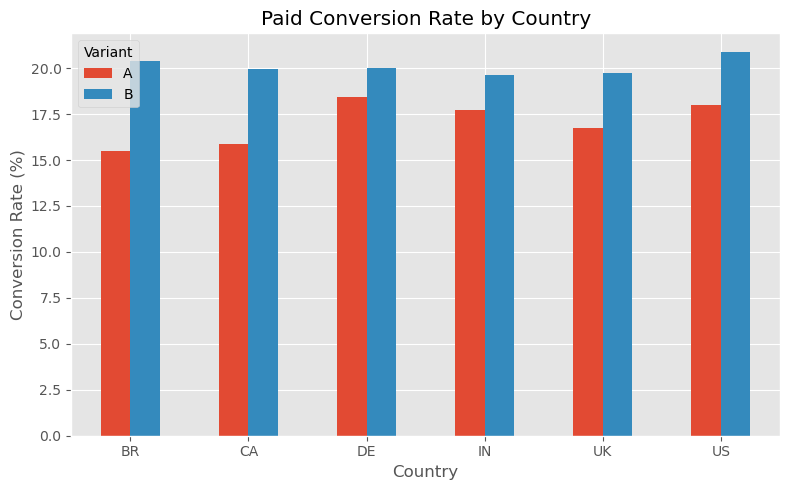

In [17]:
country_pivot.mul(100).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Paid Conversion Rate by Country")

plt.xlabel("Country")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Variant")

plt.tight_layout()

plt.show()

In [18]:
country_pivot = (
    country_summary.pivot(
        index="country",
        columns="variant",
        values="conversion_rate"
    )
)

(country_pivot * 100).round(2)

variant,A,B
country,,
BR,15.49,20.40
CA,15.85,19.94
DE,18.41,20.02
IN,17.73,19.65
UK,16.73,19.74
US,17.97,20.85


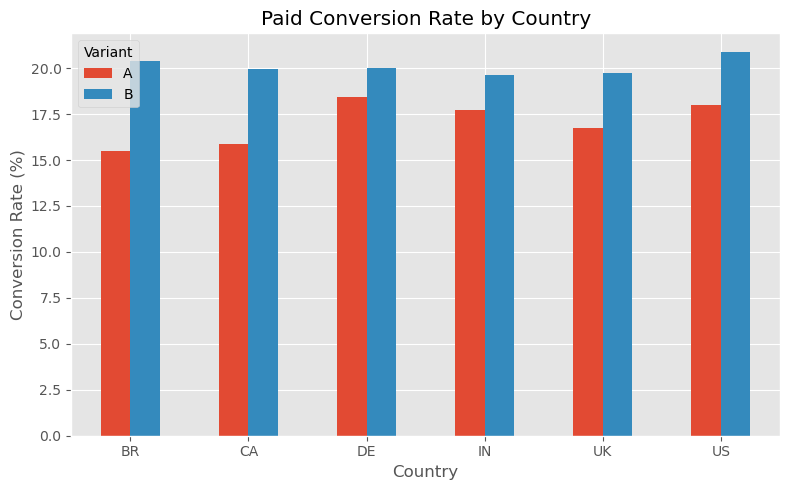

In [19]:
country_pivot.mul(100).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Paid Conversion Rate by Country")

plt.xlabel("Country")

plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=0)

plt.legend(title="Variant")

plt.tight_layout()

plt.show()

### Interpretation

Variant B improved paid conversion across every country included in the experiment.

- **Brazil (BR):** Increased from **15.49%** to **20.40%** (+4.91 percentage points)
- **Canada (CA):** Increased from **15.85%** to **19.94%** (+4.09 percentage points)
- **Germany (DE):** Increased from **18.41%** to **20.02%** (+1.61 percentage points)
- **India (IN):** Increased from **17.73%** to **19.65%** (+1.92 percentage points)
- **United Kingdom (UK):** Increased from **16.73%** to **19.74%** (+3.01 percentage points)
- **United States (US):** Increased from **17.97%** to **20.85%** (+2.88 percentage points)

The treatment outperformed the control in every geographic market. While the magnitude of the improvement varied by country, no market experienced a decline in conversion under Variant B.

The consistent improvement across countries suggests that the treatment is robust and suitable for deployment across the broader user base rather than targeting a specific geographic region.

## Guardrail Metrics

An increase in paid conversion is valuable only if it does not negatively affect downstream business outcomes.

In addition to conversion, evaluate the following guardrail metrics:

- Retention Rate
- Average Revenue per User (ARPU)
- Total Revenue

In [20]:
guardrail_summary = summary.copy()

guardrail_summary["retention_rate"] = (
    guardrail_summary["retained"]
    / guardrail_summary["users"]
)

guardrail_summary = guardrail_summary[
    [
        "users",
        "conversion_rate",
        "retention_rate",
        "average_revenue_per_user",
        "total_revenue"
    ]
]

guardrail_summary

,users,conversion_rate,retention_rate,average_revenue_per_user,total_revenue
variant,,,,,
A,19818,0.173580,0.106973,10.728429,212616.0
B,20182,0.202309,0.129918,13.072044,263820.0


### Interpretation

Variant B outperformed Variant A across all guardrail metrics.

| Metric | Variant A | Variant B |
|---------|----------:|----------:|
| Conversion Rate | 17.36% | 20.23% |
| Retention Rate | 10.70% | 12.99% |
| Average Revenue per User (ARPU) | \$10.73 | \$13.07 |
| Total Revenue | \$212,616 | \$263,820 |

Key observations:

- Paid conversion increased from **17.36%** to **20.23%**.
- Retention rate also improved, indicating that the additional conversions did not come at the expense of customer quality.
- Average revenue per user (ARPU) increased by approximately **21.8%**, suggesting that Variant B generated greater revenue from the overall user base.
- Total revenue increased by more than **$51,000** during the experiment.

These guardrail metrics indicate that the treatment not only improved the primary success metric but also had a positive impact on downstream business outcomes.

# Business Recommendation

The experiment provides strong evidence that **Variant B should be deployed as the default experience for all users.**

## Supporting Evidence

- No Sample Ratio Mismatch (SRM) was detected, indicating that users were randomly assigned between variants.
- Paid conversion increased from **17.36%** to **20.23%**, representing an **absolute uplift of 2.87 percentage points** (**16.55% relative improvement**).
- The two-proportion z-test found the improvement to be statistically significant.
- The **95% confidence interval** indicates that Variant B improves paid conversion by **2.11 to 3.64 percentage points**, providing evidence that the observed uplift is unlikely to be due to random chance.
- Segment analyses showed that Variant B outperformed Variant A across devices, acquisition channels, and countries.
- The largest improvement was observed for **mobile users** (+3.60 percentage points), while desktop users also experienced a meaningful increase (+1.68 percentage points).
- Guardrail metrics also improved, with higher retention, greater average revenue per user (ARPU), and approximately **$51,204** higher total revenue during the experiment.

## Business Impact

Variant B increased paid conversion while also improving downstream business metrics, including retention and revenue. The treatment demonstrated consistent performance across major customer segments, suggesting that the new experience generalizes well across the user population.

The segment analyses are exploratory and should be interpreted as directional insights. Additional confirmatory testing would be appropriate before making segment-specific product decisions.

## Recommendation

Deploy **Variant B** as the default experience for all users while continuing to monitor long-term retention, customer lifetime value, and revenue after rollout to ensure the observed improvements remain stable at production scale.

## Limitations

This analysis is based on a synthetic dataset created for portfolio purposes.

Several simplifying assumptions were made:

- The experiment duration was not explicitly modeled.
- Long-term customer lifetime value (LTV) was not evaluated.
- Segment analyses are exploratory and should not be interpreted as confirmatory statistical tests.
- Additional experimentation would be appropriate before making segment-specific product decisions.